<a href="https://colab.research.google.com/github/Cat0412/Autonomous-Driving-Robot-Course/blob/main/Autonomous_Robot_Yolo_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00


In [2]:
!cp "/content/drive/MyDrive/yolo_dataset/people_falls_yolov8.zip" "/content/people_falls_yolov8.zip"

In [3]:
import zipfile
import shutil
from pathlib import Path

zip_path = "/content/people_falls_yolov8.zip"
extract_dir = "/content/dataset_tmp"
target_dir = "/content/people_falls_yolov8"

shutil.rmtree(extract_dir, ignore_errors=True)
shutil.rmtree(target_dir, ignore_errors=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

yaml_files = list(Path(extract_dir).rglob("data.yaml"))

if not yaml_files:
    raise FileNotFoundError("data.yaml을 찾을 수 없습니다. 폴더 전체를 압축했는지 확인하세요.")

dataset_root = yaml_files[0].parent
shutil.move(str(dataset_root), target_dir)

print("Dataset ready:", target_dir)

Dataset ready: /content/people_falls_yolov8


In [4]:
print(open("/content/people_falls_yolov8/data.yaml", encoding="utf-8").read())

path: /content/people_falls_yolov8
train: train/images
val: valid/images
test: test/images

nc: 1
names:
  0: Fallen Person


In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/people_falls_yolov8/data.yaml",
    epochs=80,
    imgsz=640,
    batch=16,
    name="fallen_person_yolov8n"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/people_falls_yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea6d1880230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [7]:
!cp "/content/runs/detect/fallen_person_yolov8n/weights/best.pt" "/content/drive/MyDrive/yolo_dataset/best.pt"

In [8]:
from pathlib import Path

# 가장 최근 학습 결과 폴더 자동 탐색
runs_dir = Path("/content/runs/detect")
train_dirs = sorted([p for p in runs_dir.iterdir() if p.is_dir()], key=lambda p: p.stat().st_mtime)

result_dir = train_dirs[-1]
print("Result directory:", result_dir)
print("Files:")
for f in result_dir.iterdir():
    print("-", f.name)

Result directory: /content/runs/detect/fallen_person_yolov8n
Files:
- args.yaml
- BoxPR_curve.png
- results.png
- train_batch2.jpg
- val_batch2_pred.jpg
- BoxR_curve.png
- val_batch0_labels.jpg
- train_batch2452.jpg
- val_batch1_pred.jpg
- BoxP_curve.png
- train_batch1.jpg
- confusion_matrix.png
- labels.jpg
- weights
- val_batch0_pred.jpg
- train_batch0.jpg
- train_batch2451.jpg
- BoxF1_curve.png
- train_batch2450.jpg
- confusion_matrix_normalized.png
- val_batch2_labels.jpg
- results.csv
- val_batch1_labels.jpg


In [9]:
import pandas as pd

csv_path = result_dir / "results.csv"

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()  # 컬럼 공백 제거

display(df.tail(10))

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
70,71,777.708,0.30484,0.27897,0.85432,0.99926,0.96104,0.97995,0.92533,0.29986,0.28681,0.83851,0.000267,0.000267,0.000267
71,72,788.775,0.30985,0.26233,0.84837,0.99194,0.96104,0.97832,0.92676,0.30209,0.27821,0.83878,0.000243,0.000243,0.000243
72,73,799.778,0.28082,0.24406,0.84761,0.98354,0.95455,0.97044,0.91957,0.29536,0.30414,0.83158,0.000218,0.000218,0.000218
73,74,808.721,0.27634,0.22745,0.82445,0.97972,0.94108,0.96630,0.92220,0.28022,0.31039,0.82327,0.000193,0.000193,0.000193
74,75,819.502,0.29799,0.24350,0.85083,0.98509,0.94805,0.96976,0.91925,0.29013,0.29930,0.83085,0.000169,0.000169,0.000169
75,76,830.374,0.27855,0.22845,0.81916,0.97806,0.95455,0.96970,0.92636,0.29440,0.30454,0.83850,0.000144,0.000144,0.000144
76,77,839.311,0.26884,0.22440,0.82467,0.98910,0.94805,0.97100,0.92510,0.29518,0.30168,0.84149,0.000119,0.000119,0.000119
77,78,850.126,0.27885,0.22569,0.82991,0.99318,0.94619,0.97128,0.92350,0.29204,0.30008,0.83710,0.000094,0.000094,0.000094
78,79,860.676,0.25101,0.21149,0.81686,0.98658,0.95449,0.97202,0.92146,0.28126,0.29003,0.83284,0.000069,0.000069,0.000069
79,80,869.516,0.25836,0.21978,0.81099,0.98657,0.95371,0.97234,0.92417,0.27794,0.29119,0.83168,0.000045,0.000045,0.000045


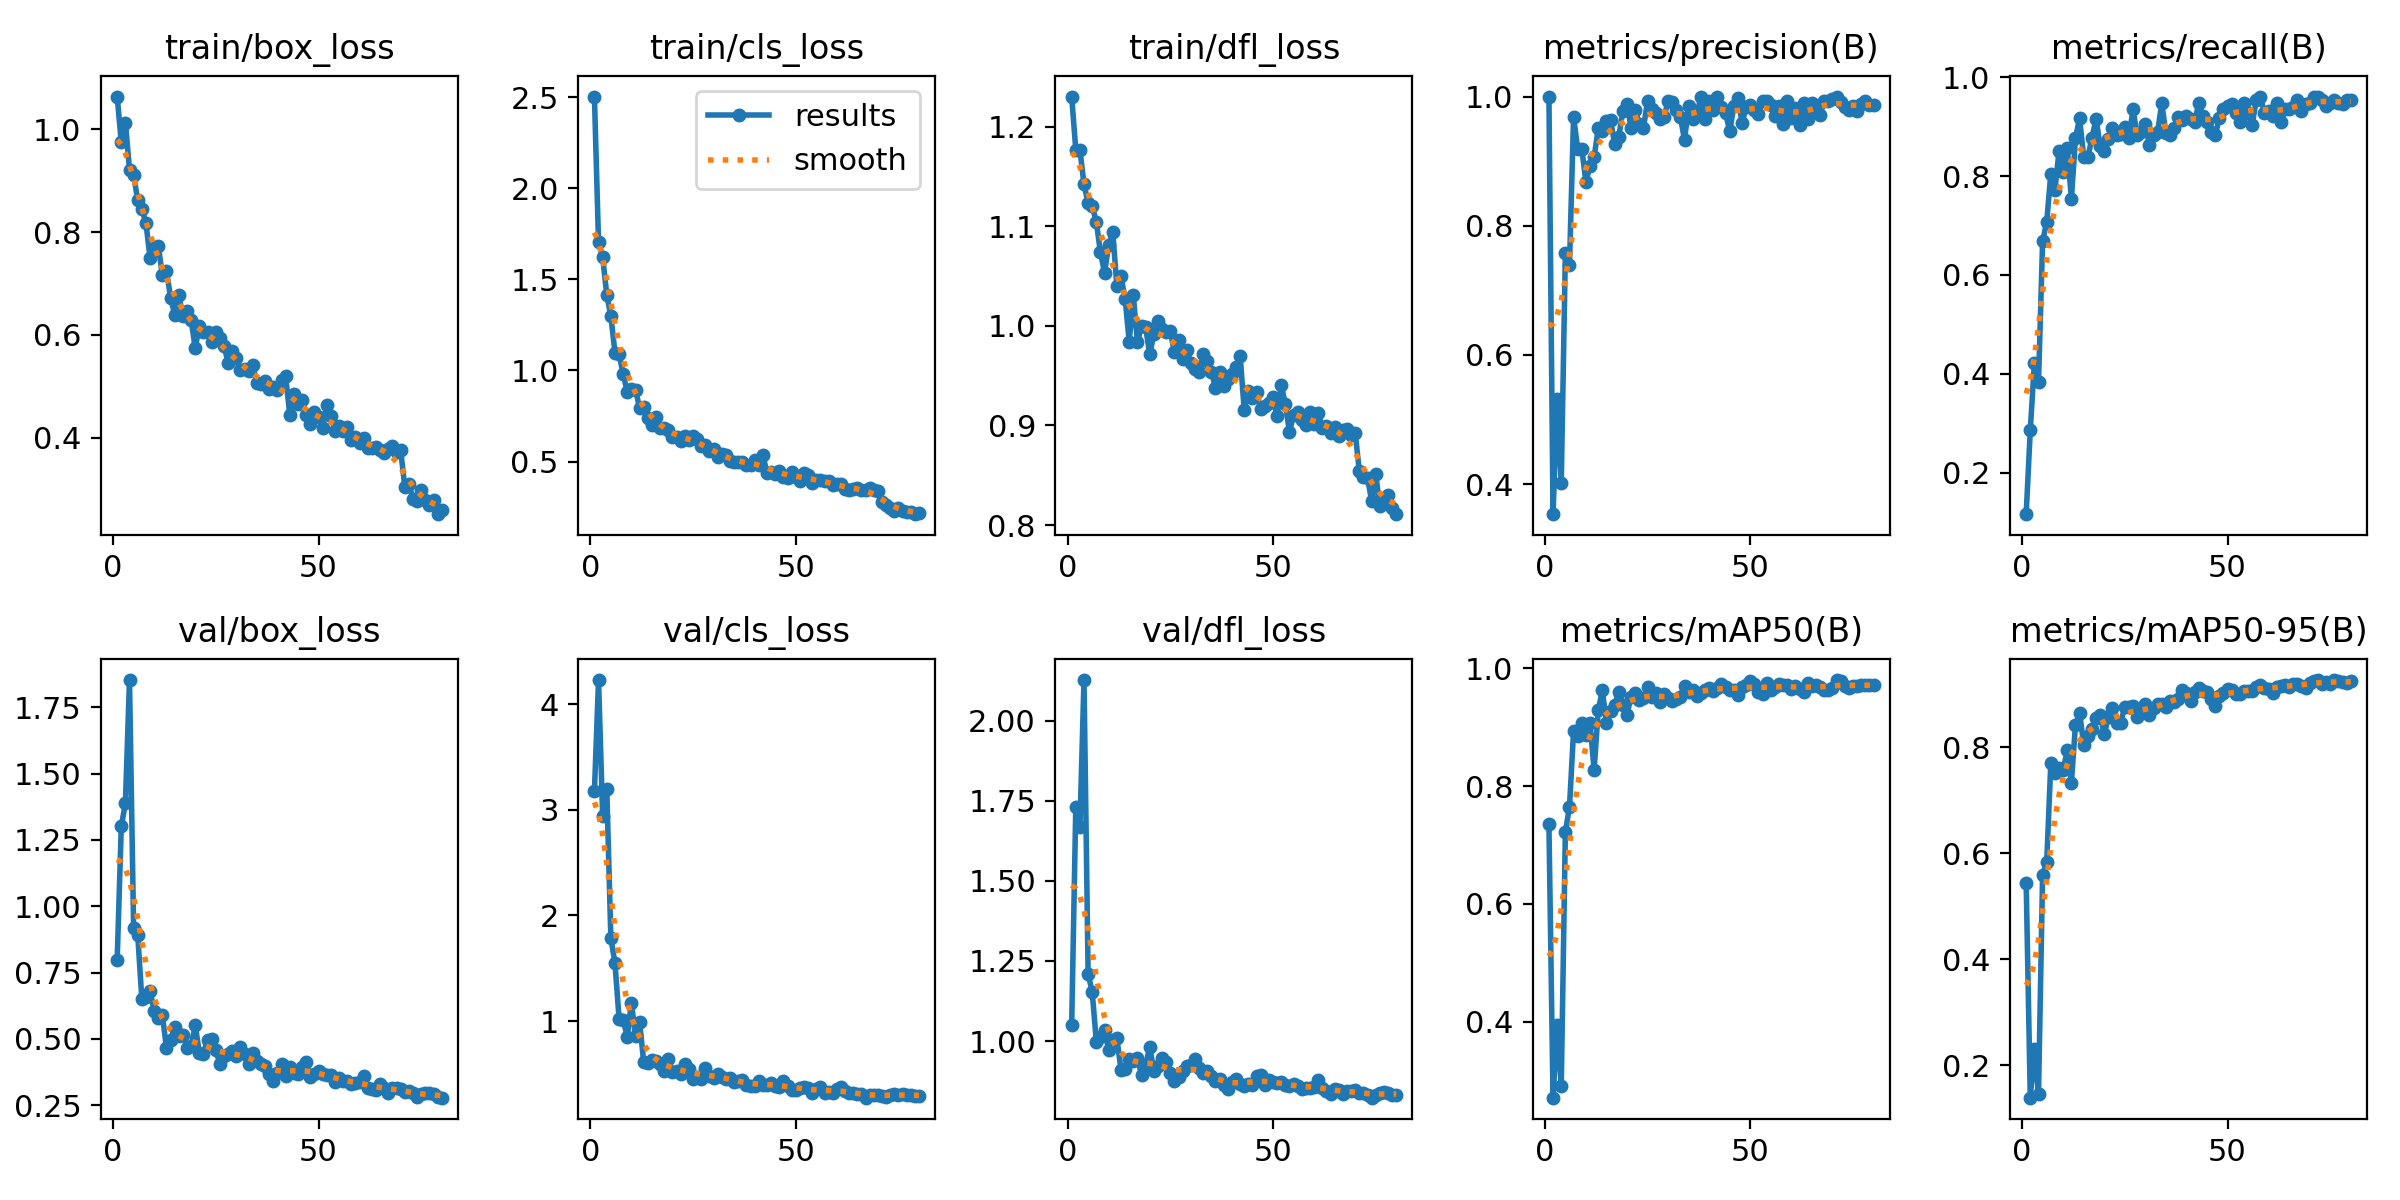

In [10]:
from IPython.display import Image, display

results_png = result_dir / "results.png"

if results_png.exists():
    display(Image(filename=str(results_png)))
else:
    print("results.png가 없습니다.")

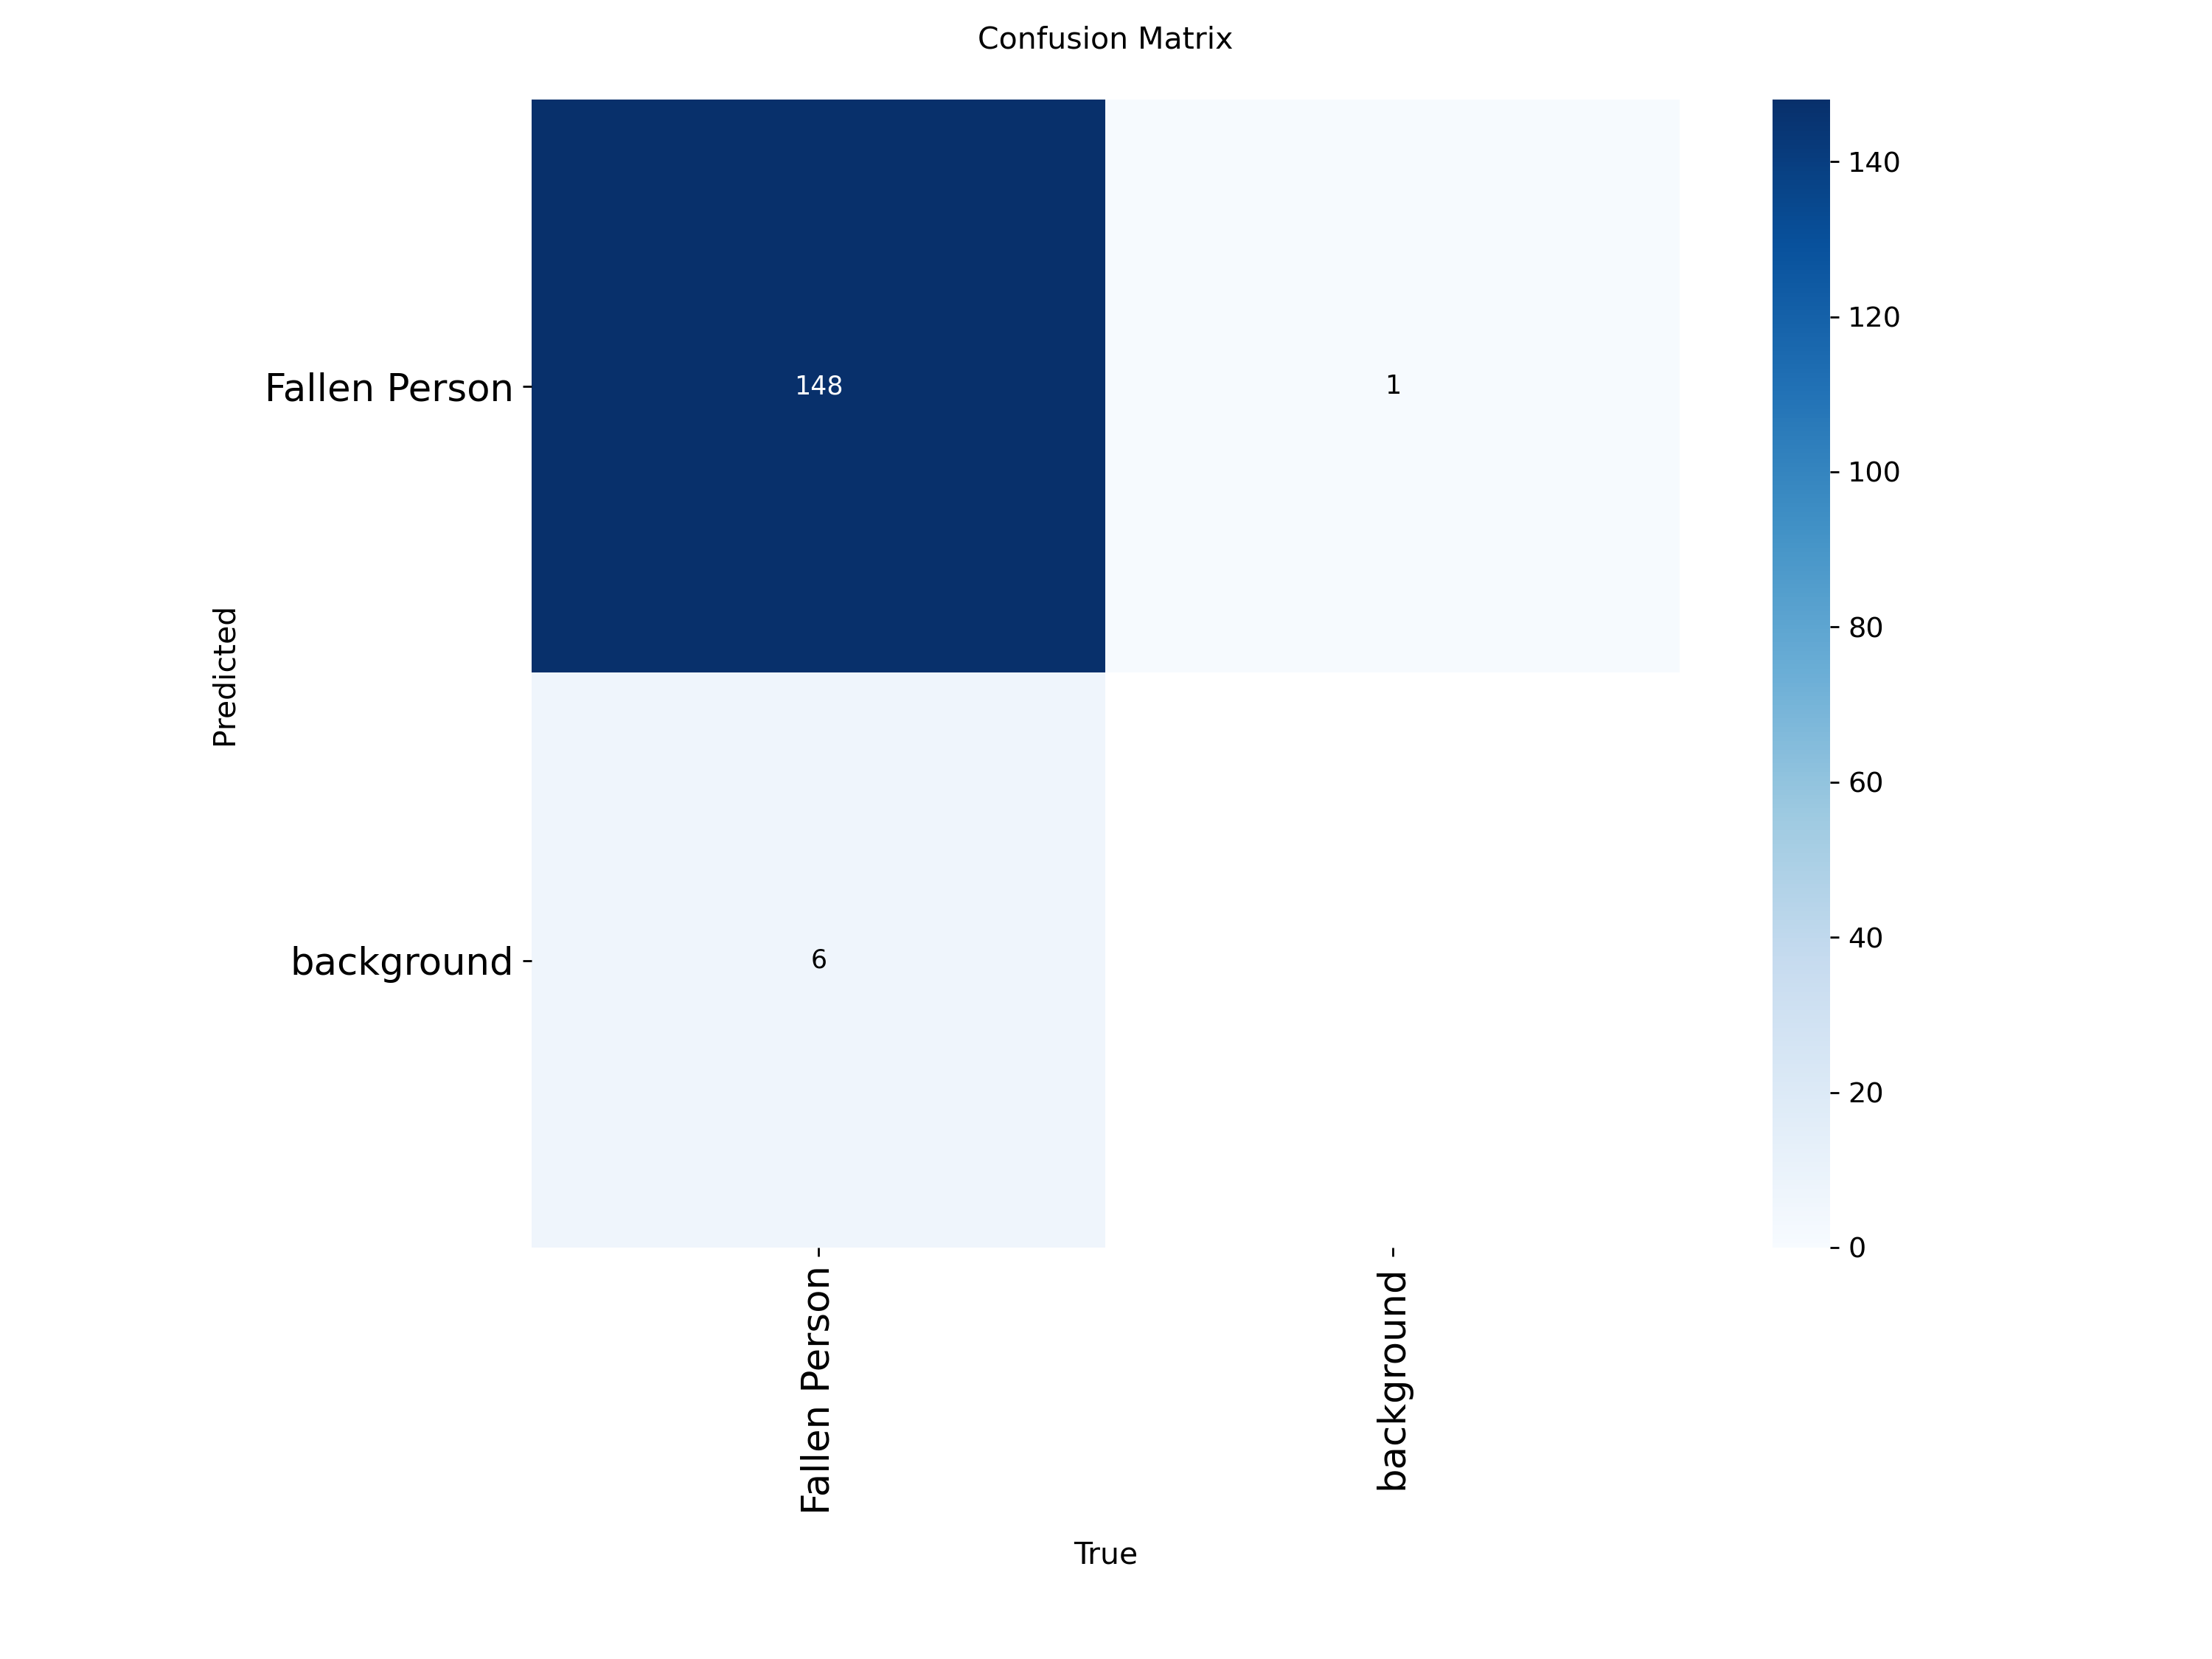

In [11]:
confusion_matrix = result_dir / "confusion_matrix.png"

if confusion_matrix.exists():
    display(Image(filename=str(confusion_matrix)))
else:
    print("confusion_matrix.png가 없습니다.")

Validation label images: 3


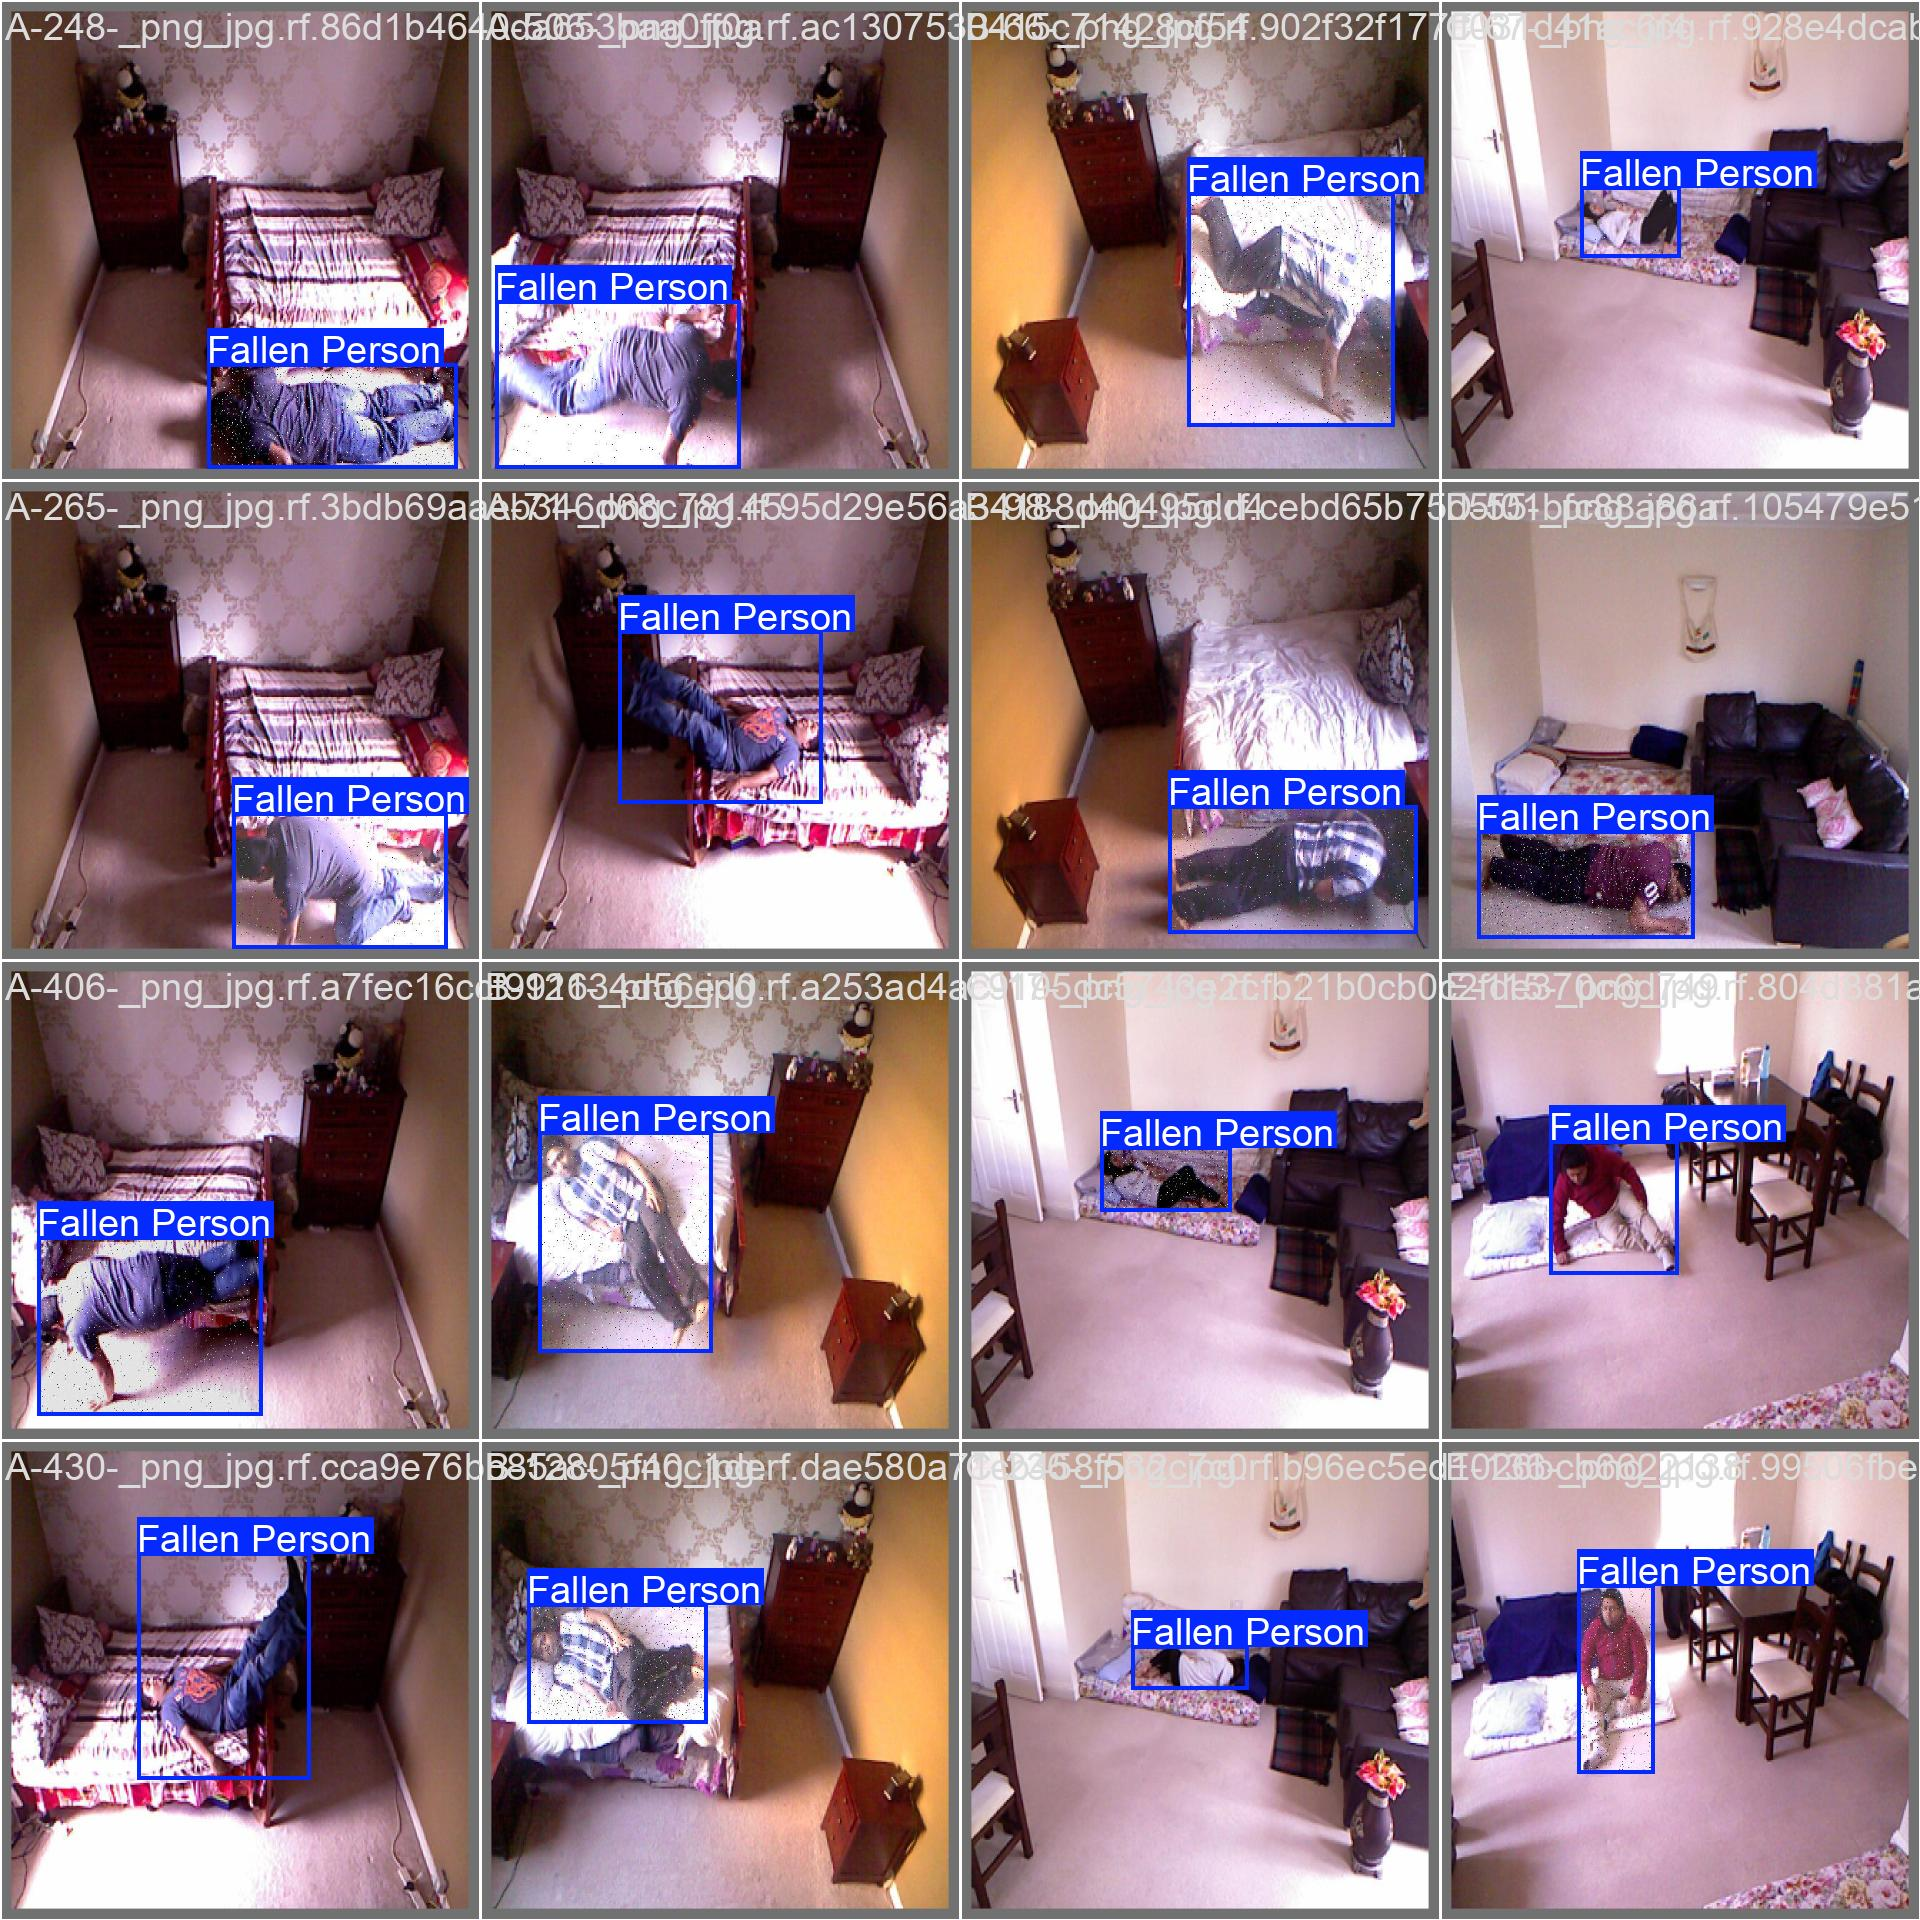

In [14]:
val_label_images = sorted(result_dir.glob("val_batch*_labels.jpg"))

print("Validation label images:", len(val_label_images))

for img in val_label_images[:1]:
    display(Image(filename=str(img)))

In [15]:
from ultralytics import YOLO

best_model_path = result_dir / "weights" / "best.pt"
model = YOLO(str(best_model_path))

test_image_dir = "/content/people_falls_yolov8/test/images"

pred_results = model.predict(
    source=test_image_dir,
    conf=0.4,
    imgsz=640,
    save=True,
    name="test_predictions"
)


image 1/75 /content/people_falls_yolov8/test/images/A-170-_png_jpg.rf.3b7add7f15b1b10f2f4dabeeb37008d5.jpg: 640x640 1 Fallen Person, 8.5ms
image 2/75 /content/people_falls_yolov8/test/images/A-210-_png_jpg.rf.44bef7c1af9066e20d2d32dd11e6a6a0.jpg: 640x640 1 Fallen Person, 7.0ms
image 3/75 /content/people_falls_yolov8/test/images/A-243-_png_jpg.rf.362905327aa936cf8bdf221f0961153c.jpg: 640x640 1 Fallen Person, 7.0ms
image 4/75 /content/people_falls_yolov8/test/images/A-250-_png_jpg.rf.29d62abdf30918bbcee342ab22fde639.jpg: 640x640 1 Fallen Person, 7.0ms
image 5/75 /content/people_falls_yolov8/test/images/A-345-_png_jpg.rf.558af3c2a5c0a27c7a54a3dd3131685a.jpg: 640x640 1 Fallen Person, 7.2ms
image 6/75 /content/people_falls_yolov8/test/images/B-137-_png_jpg.rf.14c6416a546dc144a9e68292df4b776f.jpg: 640x640 1 Fallen Person, 7.0ms
image 7/75 /content/people_falls_yolov8/test/images/B-201-_png_jpg.rf.180c75d93e61397e428bd18ff805277f.jpg: 640x640 1 Fallen Person, 7.0ms
image 8/75 /content/people

Predicted images: 75


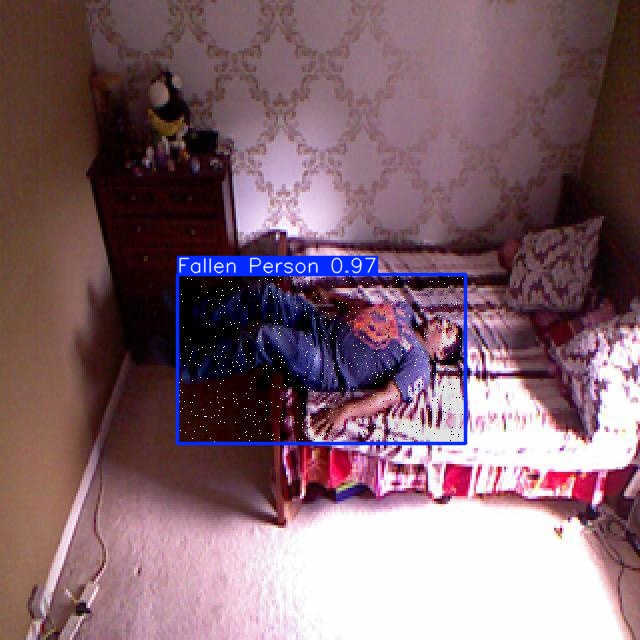

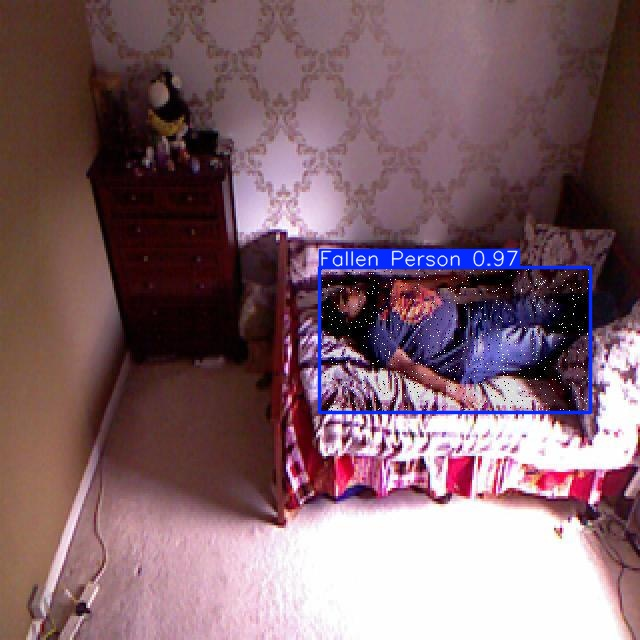

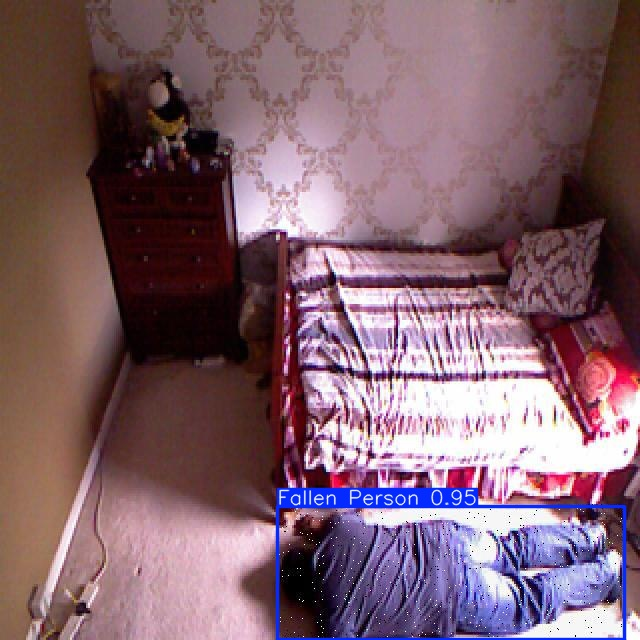

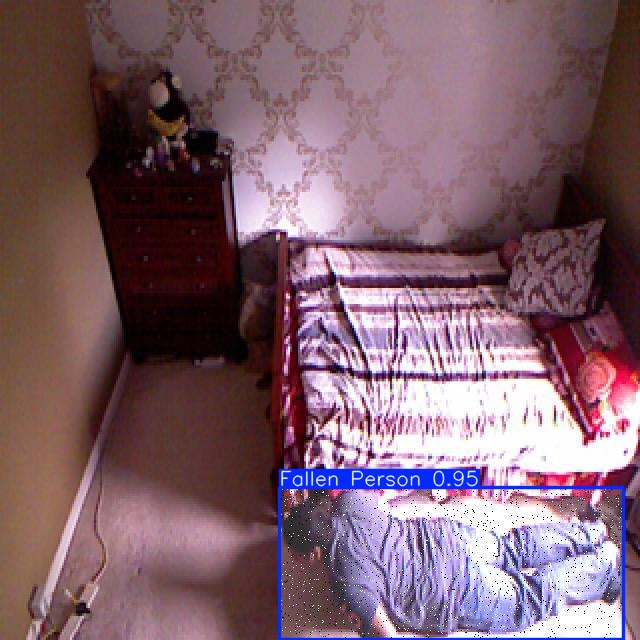

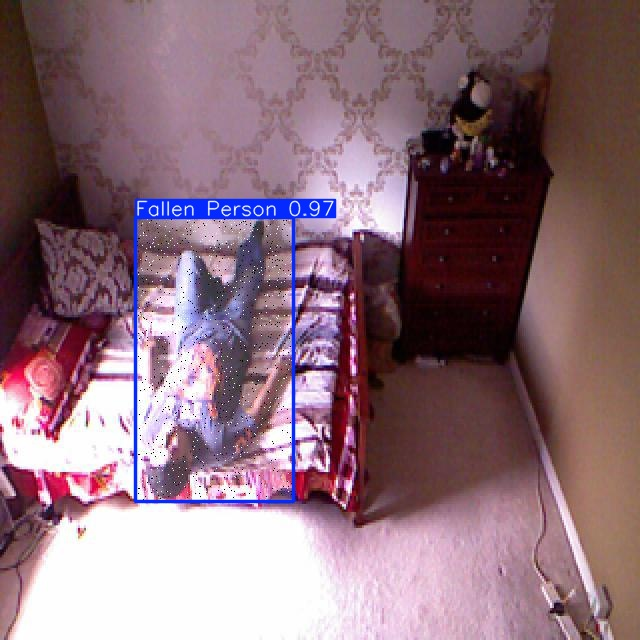

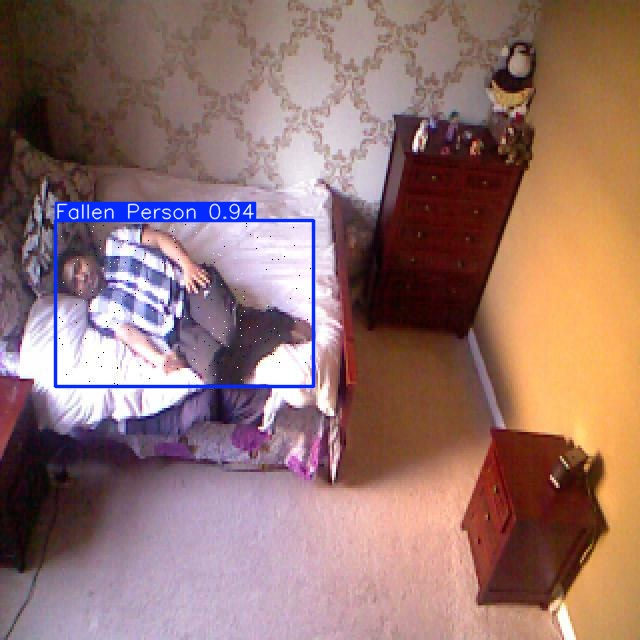

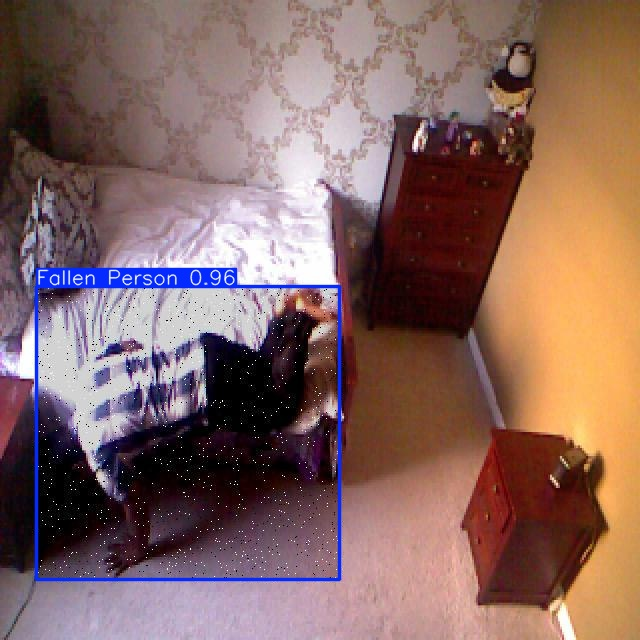

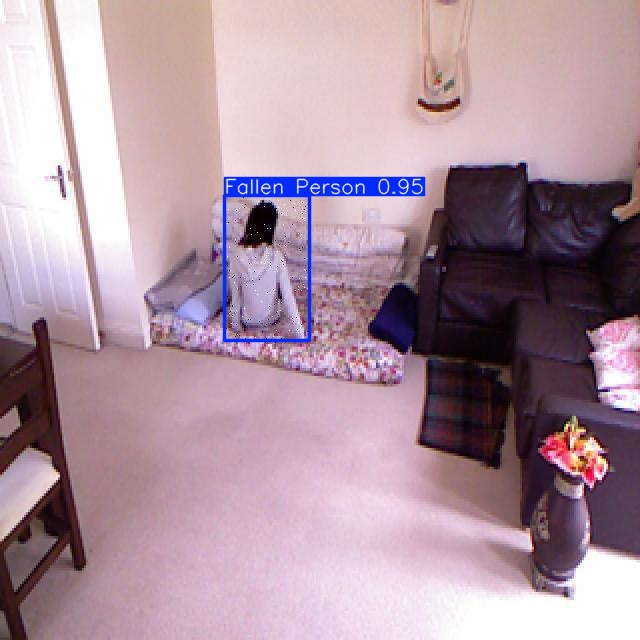

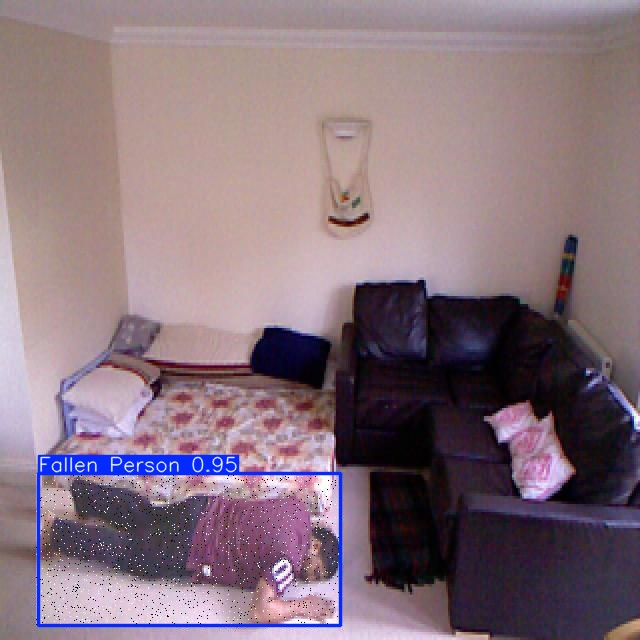

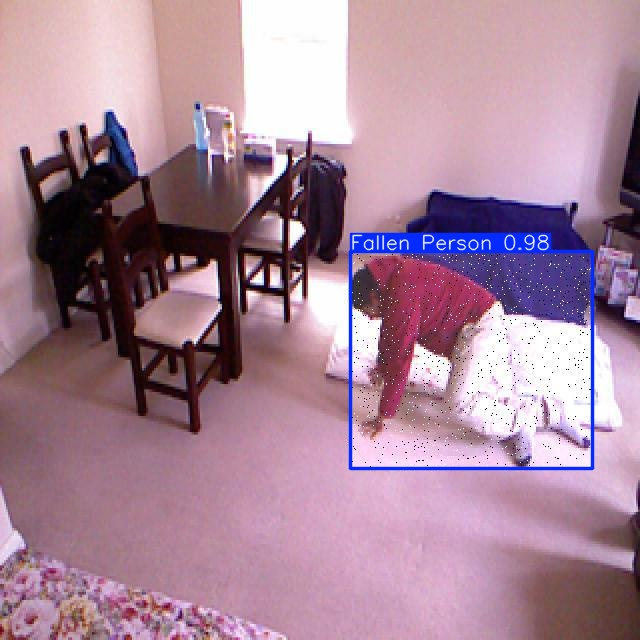

In [16]:
pred_dir = Path("/content/runs/detect/test_predictions")
pred_images = sorted(list(pred_dir.glob("*.jpg")) + list(pred_dir.glob("*.png")))

print("Predicted images:", len(pred_images))

for img in pred_images[:10]:
    display(Image(filename=str(img)))

In [17]:
import shutil
from pathlib import Path

drive_save_dir = Path("/content/drive/MyDrive/yolo_dataset/training_results")
drive_save_dir.mkdir(parents=True, exist_ok=True)

files_to_save = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

for file_name in files_to_save:
    src = result_dir / file_name
    if src.exists():
        shutil.copy(src, drive_save_dir / file_name)
        print("Saved:", file_name)

# best.pt 저장
shutil.copy(result_dir / "weights" / "best.pt", drive_save_dir / "best.pt")
print("Saved best.pt")

Saved: results.png
Saved: confusion_matrix.png
Saved: confusion_matrix_normalized.png
Saved best.pt
